# Basic demonstration of fUSi analysis

This notebook shows the basic demonstration of analyzing audio data collected at UCLA


In [60]:
%load_ext autoreload
%autoreload 2

import os
import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
from gui import *
import image_utils
from pathlib import Path
from IPython.display import HTML, Video
from SessionLoader import SessionLoader

# import nilearn as nl
from nilearn import image
from nilearn.glm.first_level import make_first_level_design_matrix
from nilearn.plotting import plot_design_matrix

import nibabel as nib


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [69]:
# add path using sessionLoader
base_path = Path('/Volumes/UCLA_collaboration/2024-06-07/UCLA_006/run-11/')
ses = SessionLoader(base_path)
ses.load_acquisition_directories(sequence_index=0) # switch between sequence

# define output path to save data, plots, and videos
ses.fUSI_corrected_path = ses.sequence_data_path / 'fUSI_corrected'
output_path = ses.fUSI_corrected_path
if not output_path.exists():
    output_path.mkdir(parents=True, exist_ok=True)

Selected sequence in the acquisitions path:
--> 0. seq-RF_full_apert_5000000Hz_5a_3c_2rp_10Dmin_40Dmax_3el_TGC0ini_50end_8000Tdur_-1Gain_3AFE_200loops

Loaded directories:

 - log_file_path:       	/Volumes/UCLA_collaboration/2024-06-07/UCLA_006/run-11/logs/task_1.log
 - task_event_file_path:  	/Volumes/UCLA_collaboration/2024-06-07/UCLA_006/run-11/streams/task_1-event_stream.h5
 - probe_event_file_path: 	/Volumes/UCLA_collaboration/2024-06-07/UCLA_006/run-11/streams/probe_1-event_stream.h5
 - sequence_data_path:  	/Volumes/UCLA_collaboration/2024-06-07/UCLA_006/run-11/acquisitions/seq-RF_full_apert_5000000Hz_5a_3c_2rp_10Dmin_40Dmax_3el_TGC0ini_50end_8000Tdur_-1Gain_3AFE_200loops
 - raw_data_path:       	/Volumes/UCLA_collaboration/2024-06-07/UCLA_006/run-11/acquisitions/seq-RF_full_apert_5000000Hz_5a_3c_2rp_10Dmin_40Dmax_3el_TGC0ini_50end_8000Tdur_-1Gain_3AFE_200loops/raw_frame_data
 - beamformed_path:     	/Volumes/UCLA_collaboration/2024-06-07/UCLA_006/run-11/acquisitions/seq-RF_ful

In [70]:
# If beamforming and power doppler have not been performed, perform them using the following commands in your terminal (make sure mangrove is activated!)
# Command to execute the mangrove raw data to beamformed conversion
beamform_command =  f'python -m mangrove.io.convert.mangrove_raw_data_to_beamformed input_mode=experiments_root_folder input_mode.experiments_root_folder="{ses.sequence_data_path}"'
power_doppler_command =  f'python -m mangrove.io.convert.beamformed_to_doppler input_mode=experiments_root_folder input_mode.experiments_root_folder="{ses.sequence_data_path}"'

print(beamform_command)
print(power_doppler_command)

python -m mangrove.io.convert.mangrove_raw_data_to_beamformed input_mode=experiments_root_folder input_mode.experiments_root_folder="/Volumes/UCLA_collaboration/2024-06-07/UCLA_006/run-11/acquisitions/seq-RF_full_apert_5000000Hz_5a_3c_2rp_10Dmin_40Dmax_3el_TGC0ini_50end_8000Tdur_-1Gain_3AFE_200loops"
python -m mangrove.io.convert.beamformed_to_doppler input_mode=experiments_root_folder input_mode.experiments_root_folder="/Volumes/UCLA_collaboration/2024-06-07/UCLA_006/run-11/acquisitions/seq-RF_full_apert_5000000Hz_5a_3c_2rp_10Dmin_40Dmax_3el_TGC0ini_50end_8000Tdur_-1Gain_3AFE_200loops"


In [72]:
# process power doppler files
fusi_data = ses.process_power_doppler_files(num_tissue_components=60)
nifti_filename = ses.save_nifti_file(fusi_data)
fusi_data = ses.load_nifti_file(nifti_filename)

# load probe and task events
probe_events = ses.probe_events

# process task events
task_events = ses.extract_task_events(behavior_offset=0)
task_events

Number of file included: 41/41
All entries in 'fusi_file_name' are properly populated.
Loading dataset from disk to memory
Loaded. releasing dataset_on_disk open-file

Loaded in fusi_data with shape: (274, 1, 227, 41)
Saved PD NIFTI in /Volumes/UCLA_collaboration/2024-06-07/UCLA_006/run-11/acquisitions/seq-RF_full_apert_5000000Hz_5a_3c_2rp_10Dmin_40Dmax_3el_TGC0ini_50end_8000Tdur_-1Gain_3AFE_200loops/fUSI_corrected
of filename: original.nii.gz
Loaded power doppler images stored in NIFTI. Shape: (274, 1, 227, 41)


,trial_type,onset,duration
0,stimulus_onset,20.019357,27.505522
1,stimulus_onset,76.662169,27.505561


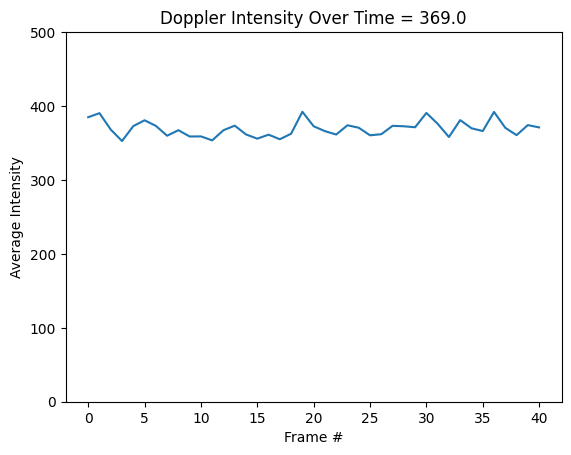

In [73]:
################################################
#     Display Doppler intensity time course    #
################################################

average_over_time = image_utils.plot_pd_intensity_over_time(fusi_data)

In [74]:
##############################################
#     Display and save power Doppler movie   #
##############################################

ani = MakeAnimation(fusi_data[:, 0], 
                    output_file=str(output_path /'pd.mp4'), 
                    fps=10, 
                    depth=ses.depth, 
                    lateral=ses.lateral, 
                    time=ses.probe_events['time_stamp'],
)
HTML(ani.to_jshtml())

# Discard out-of-plane images

In [ ]:
#############################################################################
# If needed: identify and discard any out-of-plan images                    #
#############################################################################

csv_path = output_path / 'acquisition_info.csv'
power_doppler_df = pd.read_csv(csv_path)

if 'out_of_plane_label_kmeans' in power_doppler_df.columns:

    out_of_plane_label = power_doppler_df['out_of_plane_label_kmeans']
    print(f'Out-of-plane labels:\n{np.array(out_of_plane_label)}')

    # out-of-plane frame indices
    oop_indices = np.where(np.array(out_of_plane_label) < 0)[0]

    print(f'Out-of-plane frame indices:\n{oop_indices}')

    print(f'% of out-of-plane frames: {len(oop_indices)/len(out_of_plane_label)*100:.2f}%')

    range_oop = [i for i in range(len(out_of_plane_label)-1) if out_of_plane_label[i+1] - out_of_plane_label[i] != 0]
    if len(range_oop) == 1: 
        # append last index at the end
        range_oop.append(len(out_of_plane_label))
    print(f'Range of out-of-plane frames: {range_oop}')

In [100]:
#############################################################################
# If needed: perform image registration and display transformation dynamic  #
#############################################################################

apply_image_registration = True # If true, we will register the fUSi data to the first frame. If false, we will not register the fUSi data.
plot_transformations = True
metric_name = 'mutual_information'

if apply_image_registration:
        registered_images, extra = image_utils.register_ants(fusi_data)
    if plot_transformations:
        image_utils.plot_transform_params(extra, range_oop=range_oop, metric_name=metric_name)

(274, 2, 252, 224)


Text(0, 0.5, 'Average Intensity')

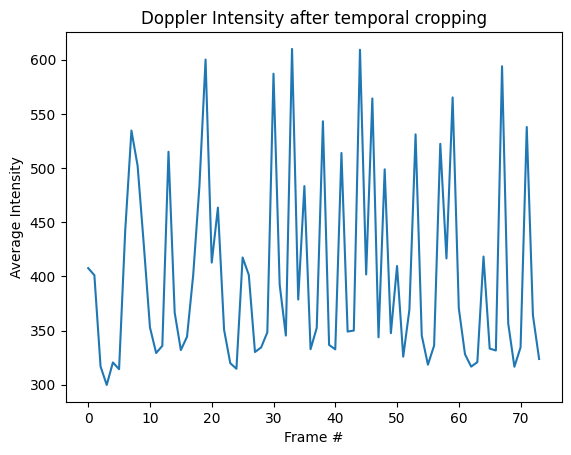

In [101]:
###############################################################################################
#     Depending on the transformation matrix, we can select a sub-period of time to study     #
###############################################################################################

study_sub_period = True
sub_period_to_study = [102, 176]

if study_sub_period:
    # Sub-period of fusi_data
    fusi_data_sub_period = fusi_data[:, :, :, sub_period_to_study[0]:sub_period_to_study[1]]
    # print(fusi_data_sub_period.shape)

    # Sub-period of probe_events
    probe_events.reset_index(drop=True, inplace=True)
    probe_events_sub_period = probe_events.iloc[sub_period_to_study[0]:sub_period_to_study[1], :].reset_index(drop=True)
    # print(probe_events_sub_period)

    # Sub-period of task events
    last_valid_index = -1
    for n in range(len(task_events)):
        if task_events.iloc[n]['onset'] + task_events.iloc[n]['duration'] > probe_events_sub_period.iloc[-1]['time_stamp']:
            last_valid_index = n - 1
            break
    # If no valid index is found, use all events; otherwise, slice up to the last valid index and reset index
    if last_valid_index == -1:
        task_events_sub = task_events.copy().reset_index(drop=True)
    else:
        task_events_sub = task_events.iloc[:last_valid_index + 1].reset_index(drop=True)
    # print(task_events_sub.shape)
    if apply_image_registration:

        # Sub-period of transformations
        transformations_sub_period = transformations[:, sub_period_to_study[0]:sub_period_to_study[1]]
        print(transformations_sub_period.shape)

        plt.figure(figsize=(10, 4))
        plt.plot(transformations_sub_period[0, :], label='Translation X')
        plt.plot(transformations_sub_period[1, :], label='Translation Y')
        plt.plot(transformations_sub_period[2, :]*180/np.pi, label='Rotation Angle')
        plt.title('Transformation after sub-period clipping')
        plt.xlabel('Frame Index')
        plt.ylabel('Transformation Value')
        plt.legend()
        plt.grid(True)
        plt.show()


average_over_time_sub_period = np.mean(fusi_data_sub_period, axis=(0, 1, 2))
plt.plot(average_over_time_sub_period)
plt.title('Doppler Intensity after temporal cropping')
plt.xlabel('Frame #')
plt.ylabel('Average Intensity')

/Users/clairenastaskin/miniforge3/envs/Anise/lib/python3.9/site-packages/nilearn/glm/first_level/hemodynamic_models.py:403: UserWarning:

Some stimulus onsets are earlier than 171.80519199371338 in the experiment and are thus not considered in the model.

/var/folders/50/vlgy95sd2d1d6w1_l8pgqd1c0000gn/T/ipykernel_1771/1594775374.py:34: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



<Figure size 640x480 with 0 Axes>

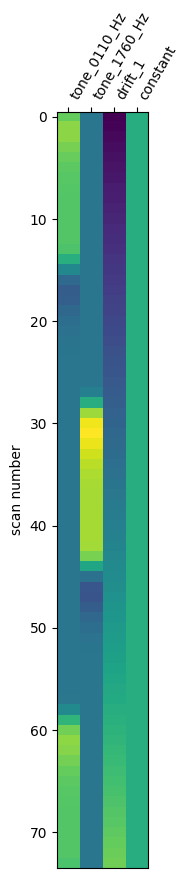

In [102]:
#######################################
#     Create design matrix for GLM    #
#######################################

if study_sub_period:
    fusi_data=fusi_data_sub_period
    probe_events=probe_events_sub_period
    task_events=task_events_sub
    # transformations=transformations_sub_period

hrf_model = "glover"
if apply_image_registration:
    transformations=transformations_sub_period
    design_matrix = make_first_level_design_matrix(
        probe_events['time_stamp'] ,
        task_events,
        drift_model="polynomial",
        drift_order=1,
        add_regs=transformations.transpose(),
        add_reg_names=["tx","ty","rot"],
        hrf_model=hrf_model,
    )
else:
    design_matrix = make_first_level_design_matrix(
        probe_events['time_stamp'] ,
        task_events,
        drift_model="polynomial",
        drift_order=1,
        hrf_model=hrf_model,
    )

fig = plt.figure()
plot_design_matrix(design_matrix)
fig.show()

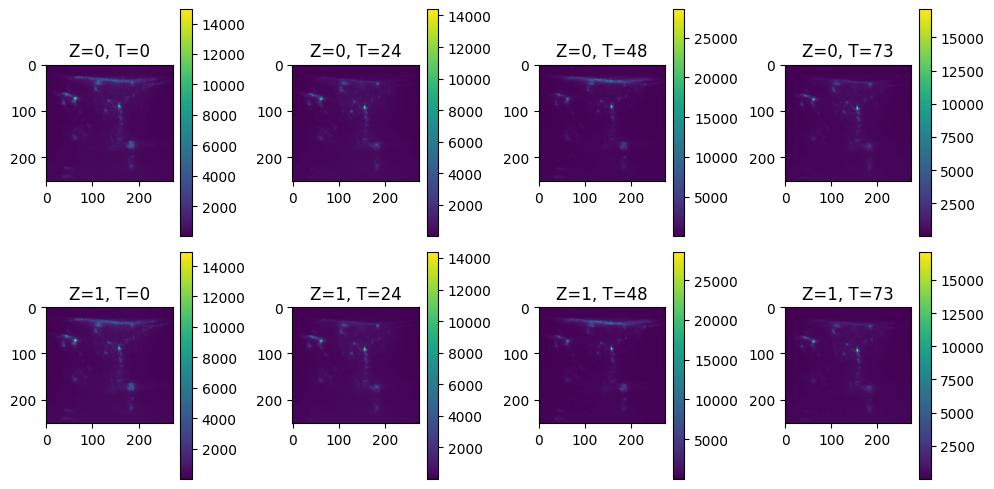

In [103]:
# Plot the data, make sure nothing crazy is happening, in particular, as I am mocking a 3D scan to play nice with nilearn, we need to make sure the data is in the right shape and the info across the second dimension is simply a copy
import matplotlib.pyplot as plt
# visualize to ensure we are getting what we think we should be getting!

fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(10, 5))  # 2 rows for Z dimension, 4 columns for T dimension
for z_dim in range(2):  # Loop over the Z dimension (1 dimension)
    for t_index, t_dim in enumerate(np.linspace(0, fusi_data.shape[3] - 1, 4, dtype=int)):  # Sample 4 equally spaced indices along the T dimension
        ax = axs[z_dim, t_index]
        img_plot = ax.imshow(np.flip(fusi_data[:, z_dim, :, t_dim].transpose(), axis=0), aspect='equal')
        ax.set_title(f'Z={z_dim}, T={t_dim}')
        plt.colorbar(img_plot, ax=ax)

plt.tight_layout()
plt.show()

In [104]:
from nilearn.signal import butterworth

affine=np.diag([.15,.15,.15,0])
# pd=np.array(fusi_data)
def boxcar_smooth(data, window_size):
    if window_size>0:
        smoothed_data = np.copy(data)
        for t in range(data.shape[3]):
            start_index = max(0, t - window_size // 2)
            end_index = min(data.shape[3], t + window_size // 2 + 1)
            smoothed_data[:, :, :, t] = np.mean(data[:, :, :, start_index:end_index], axis=3)
    else:
        smoothed_data=data
    return smoothed_data

window_size = 4 # Number of time points for smoothing
pd = boxcar_smooth(fusi_data, window_size)
nifti_img = nib.Nifti1Image(pd, affine)
nifti_img.to_filename(dm.fUSI_data_path/"fUSi_data.nii.gz")
nifti_data=image.load_img(dm.fUSI_data_path/"fUSi_data.nii.gz")
nifti_data.shape

(274, 2, 252, 74)

In [105]:
# This cell creates an identity matrix of size equal to the number of columns in the design_matrix.
# It then constructs a dictionary named 'basic_contrasts' where each key is a column name from the design_matrix
# and the corresponding value is a row from the identity matrix. This effectively sets up basic contrasts
# for each experimental condition represented in the design_matrix.

contrast_matrix = np.eye(design_matrix.shape[1])
basic_contrasts = {
    column: contrast_matrix[i]
    for i, column in enumerate(design_matrix.columns)
}
basic_contrasts

{'tone_0110_Hz': array([1., 0., 0., 0.]),
 'tone_1760_Hz': array([0., 1., 0., 0.]),
 'drift_1': array([0., 0., 1., 0.]),
 'constant': array([0., 0., 0., 1.])}

In [106]:
from nilearn.glm.first_level import FirstLevelModel
smoothing_fwhm=.5 #0 spatial smoothing in mm to apply to the data before computing GLM

# Initialize and fit the GLM model with specified parameters
print("Fitting a GLM")
fmri_glm = FirstLevelModel(minimize_memory=False,mask_img=False,smoothing_fwhm=smoothing_fwhm,standardize=True)
fmri_glm = fmri_glm.fit(nifti_data, design_matrices=design_matrix)

Fitting a GLM


Computing contrasts
	contrast id: tone_0110_Hz


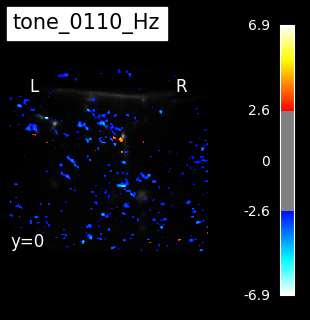

	contrast id: tone_1760_Hz


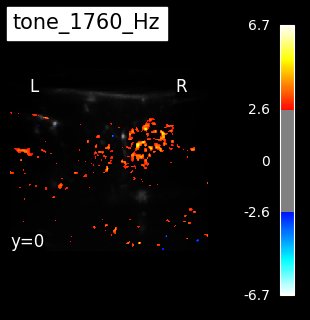

	contrast id: drift_1


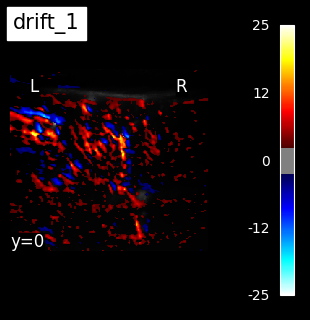

	contrast id: constant


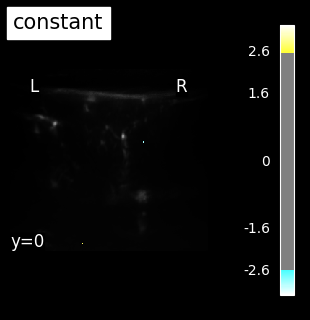

In [107]:
from nilearn import plotting
from nilearn.image import concat_imgs, mean_img, resample_img
import scipy.io
import os

print("Computing contrasts")

mean_image = mean_img(nifti_data)
base_path = "path/to/save/mat/files"  # Define the base path to save .mat files
os.makedirs(base_path, exist_ok=True)  # Create the directory if it doesn't exist

# Iterate on contrasts
for contrast_id, contrast_val in basic_contrasts.items():
    print(f"\tcontrast id: {contrast_id}")
    # compute the contrasts
    z_map = fmri_glm.compute_contrast(contrast_val, output_type="stat")
    # Save z_map in .mat format in the base_path folder
    scipy.io.savemat(os.path.join(base_path, f"{contrast_id}_z_map.mat"), {'z_map': z_map.get_fdata()})
    # plot the contrasts as soon as they're generated
    # the display is overlaid on the mean fMRI image
    # a threshold of 3.5 is used, more sophisticated choices are possible
    plotting.plot_stat_map(
        z_map,
        bg_img=mean_image,
        threshold=2.58,        
        cut_coords=[0],
        display_mode="y",        
        black_bg=True,        
        title=contrast_id,
    )
    plotting.show()

# Plot time series for ROI response and stimulus regressor

Identify ROIs using an automated clustering approach. Extract the time series for each ROI. Plot the time series and corresponding locations.



In [108]:
behavior_offset = 0 # in seconds

Processing contrast: tone_0110_Hz
Processing contrast: tone_1760_Hz


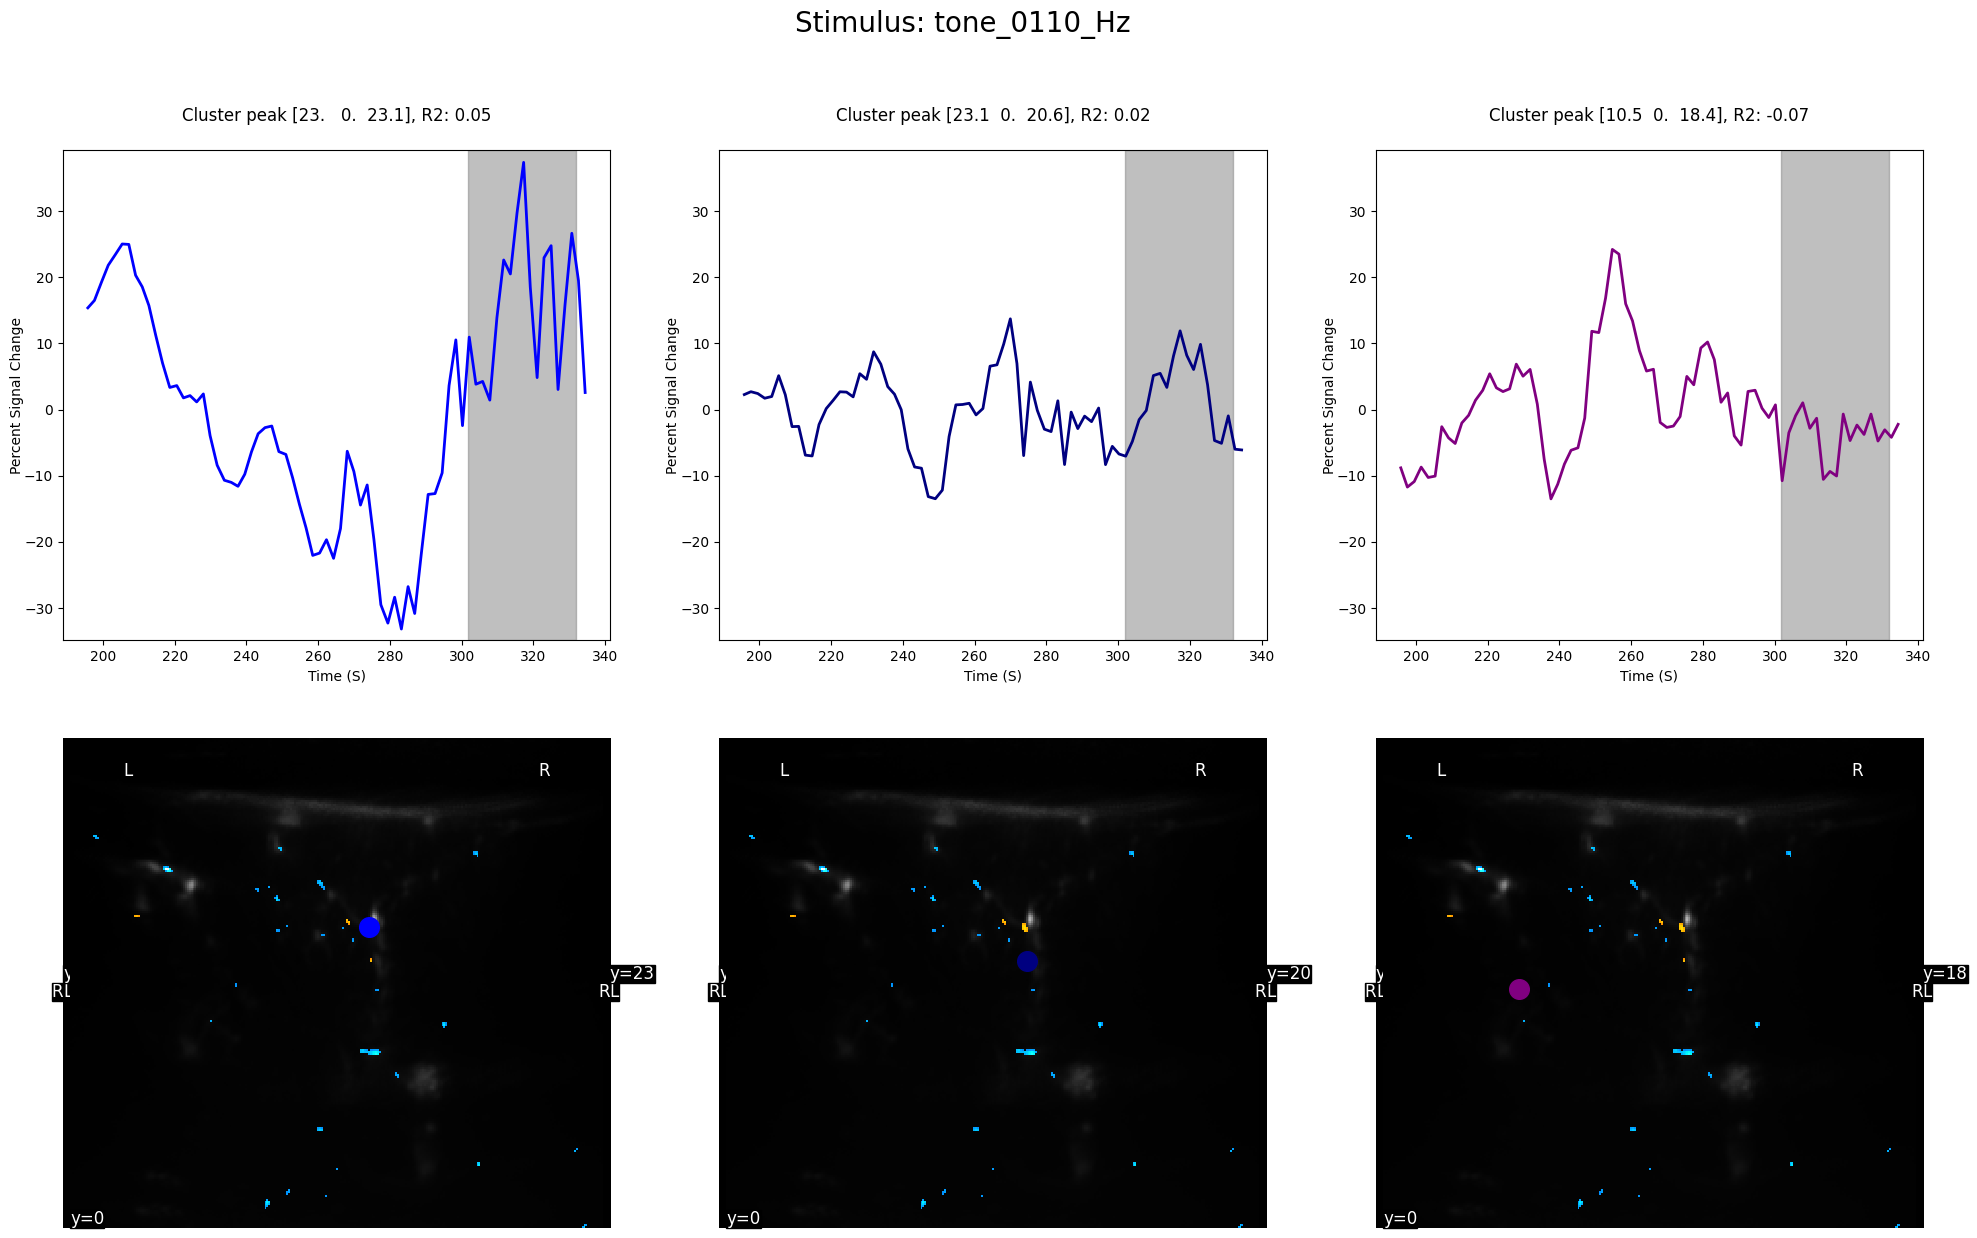

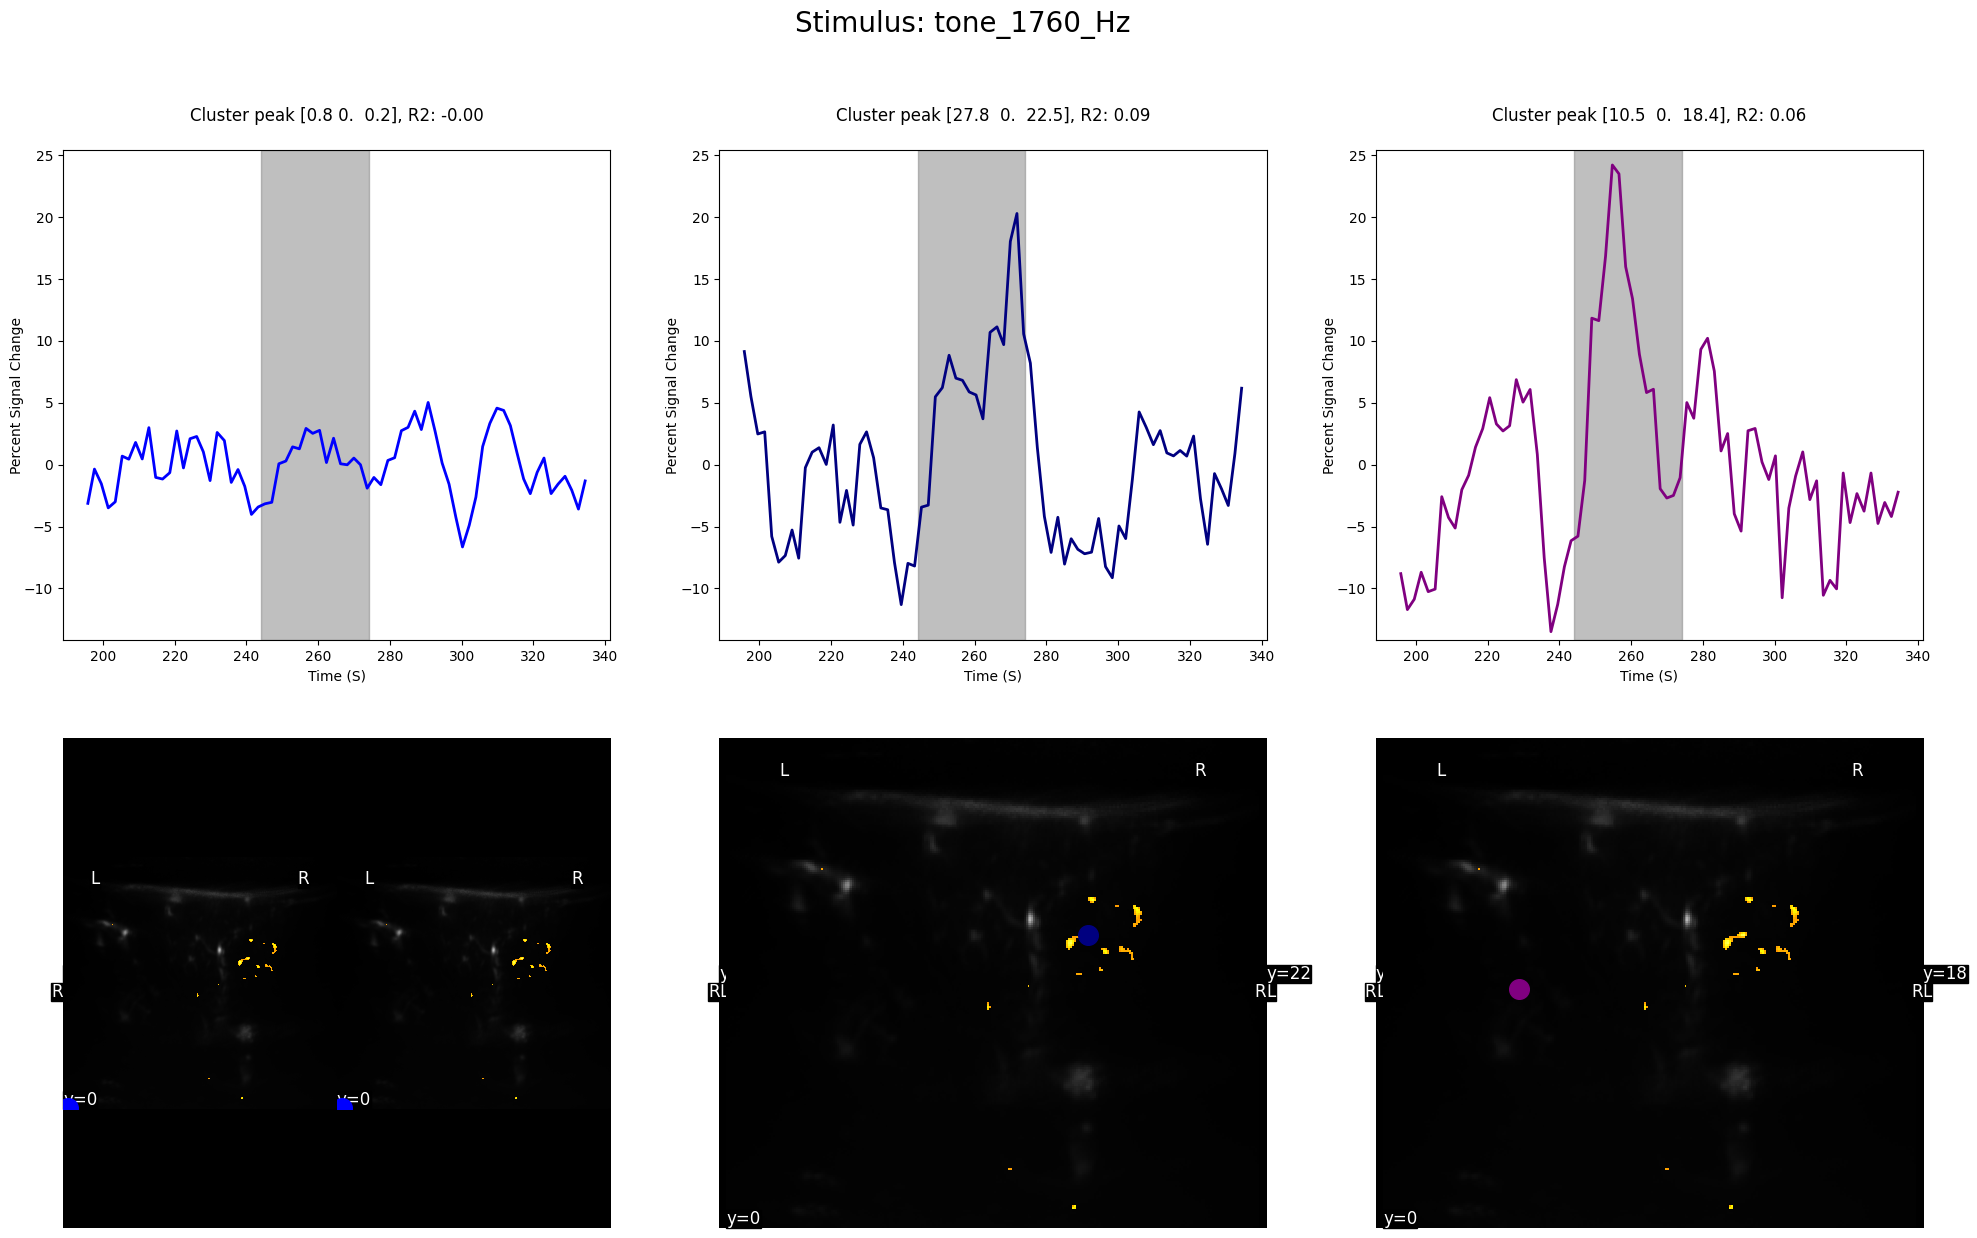

In [126]:
from nilearn.maskers import NiftiSpheresMasker
from nilearn.reporting import get_clusters_table
import numpy as np

stat_threshold = 1
num_locations = 2  # How many ROIs to visualize. An additional random ROI will be added

# Find ROIs by identifying the locations that show a significant response to the stimulus
mean_image = mean_img(nifti_data)

# Loop over all conditions in basic_contrasts
for contrast_id, contrast_val in basic_contrasts.items():
    if contrast_id not in ['drift_1', 'constant','tx','ty','rot']:
        print(f"Processing contrast: {contrast_id}")
        z_map = fmri_glm.compute_contrast(contrast_val, output_type="stat")
        table = get_clusters_table(z_map, stat_threshold=stat_threshold, cluster_threshold=20)
        table.set_index("Cluster ID", drop=True)

        if not table.empty and len(table) >= num_locations:
            # get the num_locations largest clusters' max x, y, and z coordinates
            coords = table.loc[range(0, num_locations), ["X", "Y", "Z"]].values
            coords = np.vstack([coords, [10.45000061, 0., 18.40000045]])

            # Now use the ROIs to extract the time series 
            masker = NiftiSpheresMasker(
                coords,
                radius=0.1,  # specifies the size of the spherical region around each given coordinate from which the signal will be extracted
                detrend=True,
                standardize="psc",  # zscore psc
                t_r=2.58,
                memory_level=1,
                verbose=0,
            )
            real_timeseries = masker.fit_transform(nifti_data)
            predicted_timeseries = np.tile(design_matrix[contrast_id].values, (real_timeseries.shape[1], 1)).T

            from sklearn.metrics import r2_score

            # Calculate the R-squared value for each ROI
            r_squared_values = []
            for i in range(real_timeseries.shape[1]):
                r_squared = r2_score(real_timeseries[:, i], predicted_timeseries[:, i])
                r_squared_values.append(r_squared)
            
            # Plotting the time series for each ROI and the corresponding location of each ROI
            colors = ["blue", "navy", "purple", "magenta", "olive", "teal"]
            N = real_timeseries.shape[-1]
            fig1, axs1 = plt.subplots(2, N)
            fig1.suptitle(f"Stimulus: {contrast_id}", fontsize=20)  # Set the title of the figure with a bigger font size
            # get plot limits, common across all axis
            mx = real_timeseries.max() + 0.05 * real_timeseries.max()
            mn = real_timeseries.min() + 0.05 * real_timeseries.min()

            for i in range(N):
                # plotting time series
                axs1[0, i].set_title(f"Cluster peak {coords[i].round(1)}, R2: {r_squared_values[i]:.2f}\n")
                if masker.standardize != "psc":
                    axs1[0, i].plot(probe_events['time_stamp'], predicted_timeseries[:, i], c="k", ls="--", lw=1)

                axs1[0, i].plot(probe_events['time_stamp'], real_timeseries[:, i], c=colors[i], lw=2)

                axs1[0, i].set_xlabel("Time (S)")

                if masker.standardize == "psc":
                    axs1[0, i].set_ylabel('Percent Signal Change', labelpad=0)
                else:
                    axs1[0, i].set_ylabel("Signal intensity", labelpad=0)

                # plotting image below the time series
                for index, row in task_events.iterrows():
                    if row['trial_type'] == contrast_id and row['onset'] > probe_events['time_stamp'].iloc[0]:
                        axs1[0, i].axvspan(row['onset'] + behavior_offset, row['onset'] + row['duration'] + behavior_offset, color='gray', alpha=0.5)
                roi_img = plotting.plot_stat_map(
                    z_map,
                    cut_coords=coords[i],
                    threshold=4,
                    figure=fig1,
                    axes=axs1[1, i],
                    display_mode="y",
                    colorbar=False,
                    bg_img=mean_image,
                )

                axs1[0, i].set_ylim(mn, mx)
                roi_img.add_markers([coords[i]], colors[i], 200)
            fig1.set_size_inches(24, 14)
        else:
            print(f"No valid clusters found for {contrast_id} that meet the criteria.")

Processing contrast: tone_0110_Hz


/Users/clairenastaskin/miniforge3/envs/Anise/lib/python3.9/site-packages/nilearn/signal.py:261: UserWarning:

Detrending of 3D signal has been requested but would lead to zero values. Skipping.

/Users/clairenastaskin/miniforge3/envs/Anise/lib/python3.9/site-packages/nilearn/signal.py:74: UserWarning:

Standardization of 3D signal has been requested but would lead to zero values. Skipping.

/Users/clairenastaskin/miniforge3/envs/Anise/lib/python3.9/site-packages/nilearn/signal.py:261: UserWarning:

Detrending of 3D signal has been requested but would lead to zero values. Skipping.

/Users/clairenastaskin/miniforge3/envs/Anise/lib/python3.9/site-packages/nilearn/signal.py:74: UserWarning:

Standardization of 3D signal has been requested but would lead to zero values. Skipping.

/Users/clairenastaskin/miniforge3/envs/Anise/lib/python3.9/site-packages/nilearn/signal.py:261: UserWarning:

Detrending of 3D signal has been requested but would lead to zero values. Skipping.

/Users/clairenast

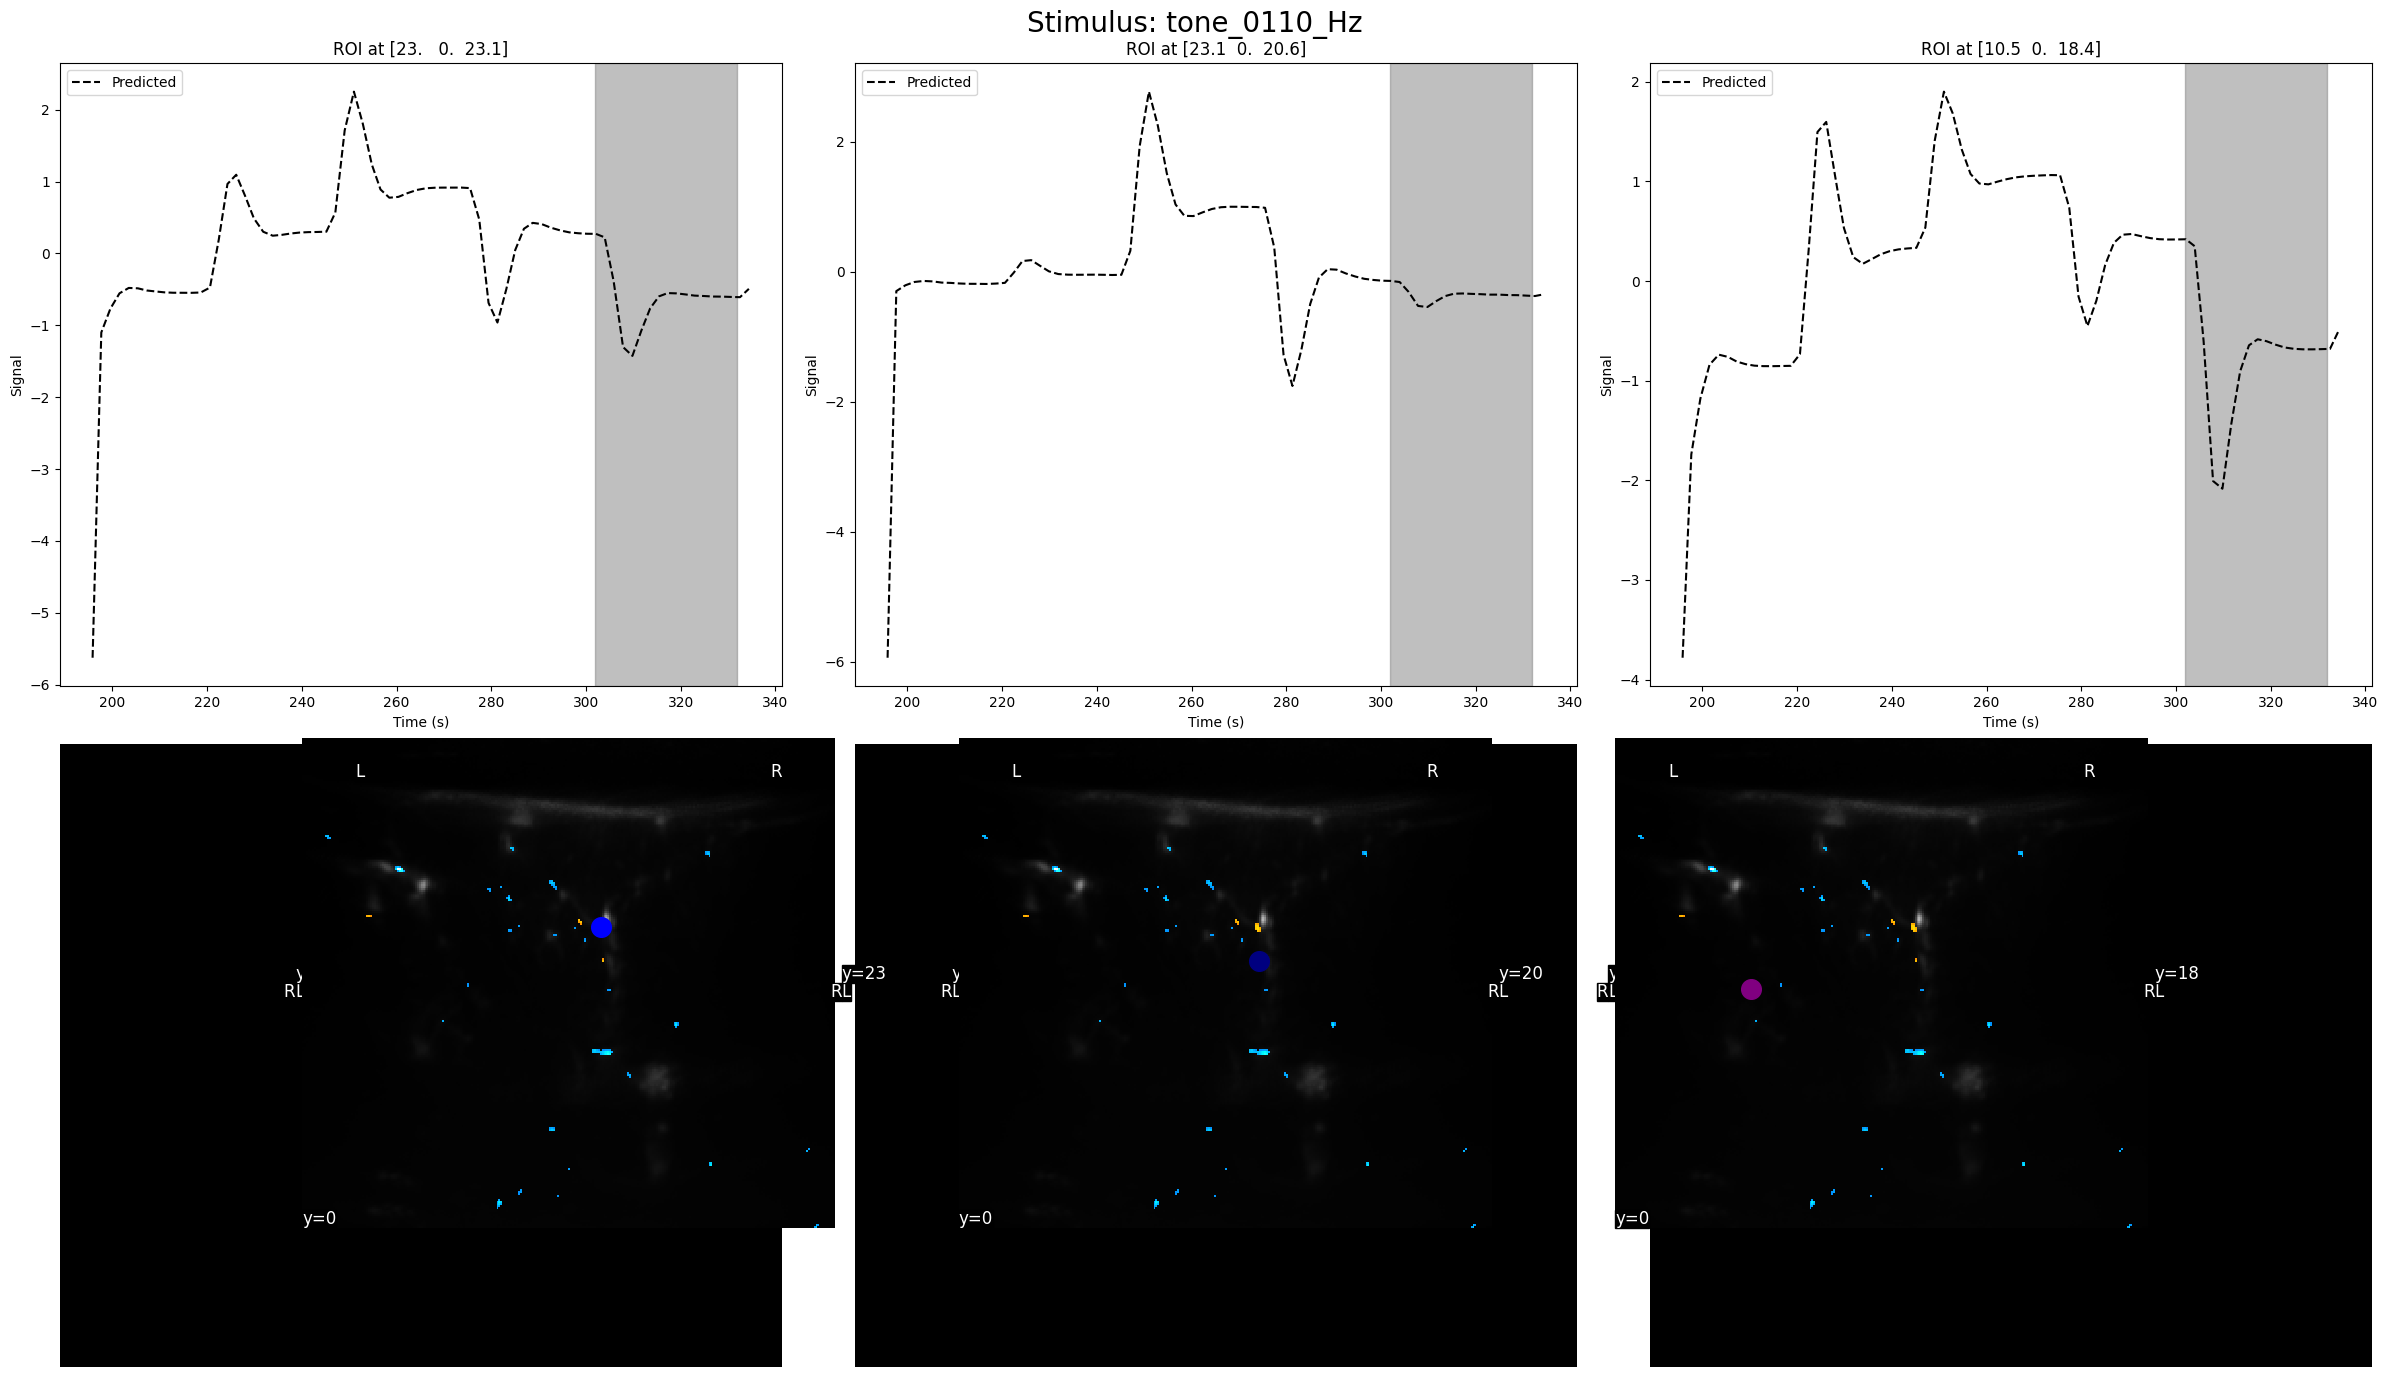

Processing contrast: tone_1760_Hz


/Users/clairenastaskin/miniforge3/envs/Anise/lib/python3.9/site-packages/nilearn/signal.py:261: UserWarning:

Detrending of 3D signal has been requested but would lead to zero values. Skipping.

/Users/clairenastaskin/miniforge3/envs/Anise/lib/python3.9/site-packages/nilearn/signal.py:74: UserWarning:

Standardization of 3D signal has been requested but would lead to zero values. Skipping.

/Users/clairenastaskin/miniforge3/envs/Anise/lib/python3.9/site-packages/nilearn/signal.py:261: UserWarning:

Detrending of 3D signal has been requested but would lead to zero values. Skipping.

/Users/clairenastaskin/miniforge3/envs/Anise/lib/python3.9/site-packages/nilearn/signal.py:74: UserWarning:

Standardization of 3D signal has been requested but would lead to zero values. Skipping.

/Users/clairenastaskin/miniforge3/envs/Anise/lib/python3.9/site-packages/nilearn/signal.py:261: UserWarning:

Detrending of 3D signal has been requested but would lead to zero values. Skipping.

/Users/clairenast

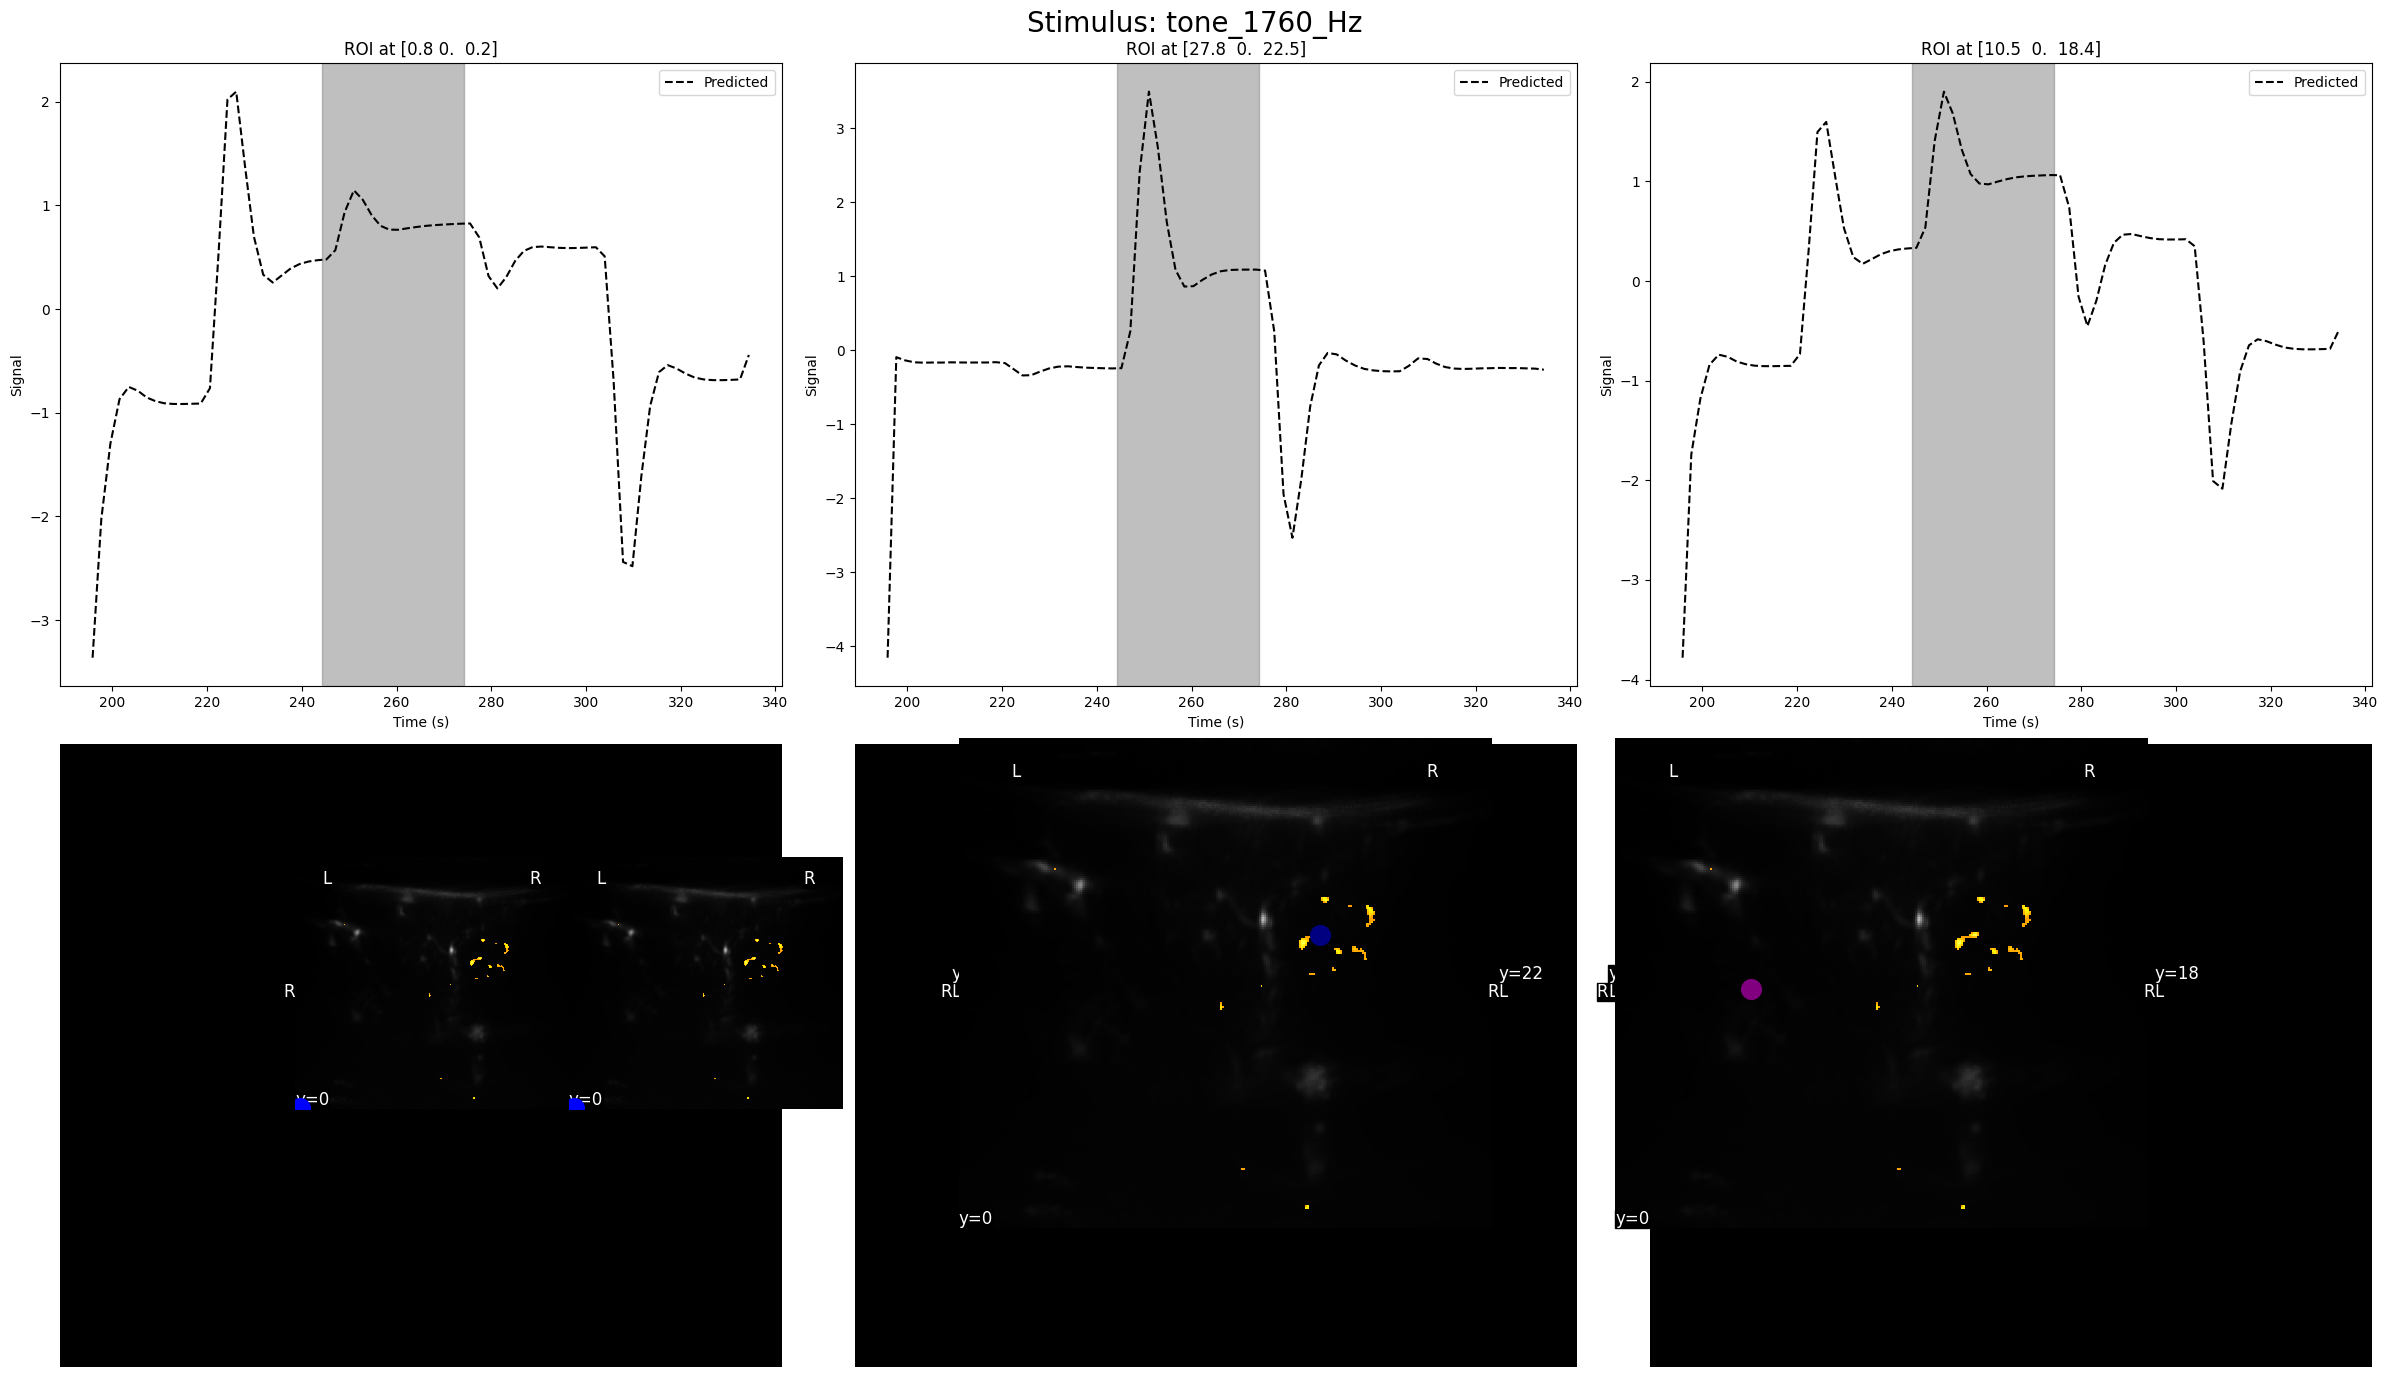

In [128]:
from nilearn.maskers import NiftiSpheresMasker
from nilearn.reporting import get_clusters_table
import numpy as np
import matplotlib.pyplot as plt
from nilearn import plotting

stat_threshold = 1
num_locations = 2  # How many ROIs to visualize. An additional random ROI will be added

# Find ROIs by identifying the locations that show a significant response to the stimulus
mean_image = mean_img(nifti_data)

# Loop over all conditions in basic_contrasts
for contrast_id, contrast_val in basic_contrasts.items():
    if contrast_id not in ['drift_1', 'constant', 'tx', 'ty', 'rot']:
        print(f"Processing contrast: {contrast_id}")
        z_map = fmri_glm.compute_contrast(contrast_val, output_type="stat")
        table = get_clusters_table(z_map, stat_threshold=stat_threshold, cluster_threshold=20)
        
        if not table.empty and len(table) >= num_locations:
            coords = table.loc[range(0, num_locations), ["X", "Y", "Z"]].values
            coords = np.vstack([coords, [10.45000061, 0., 18.40000045]])

            masker = NiftiSpheresMasker(
                coords,
                radius=3,
                detrend=True,
                standardize="zscore",
                t_r=2.58,
                memory_level=1,
                verbose=0,
                allow_overlap=True
            )
            real_timeseries = masker.fit_transform(nifti_data)
            predicted_timeseries = masker.fit_transform(fmri_glm.predicted[0])

            # Compute predicted time series for each contrast
            contrast_predicted_timeseries = {}
            for key in basic_contrasts.keys():
                contrast_effect = fmri_glm.compute_contrast(basic_contrasts[key], output_type='effect_size')
                # Ensure the effect size image is correctly transformed into a time series
                contrast_predicted = masker.fit_transform(contrast_effect.slicer[:,:,:,0])  # Adjust slicing if necessary
                contrast_predicted_timeseries[key] = contrast_predicted
                # print(f"Shape of predicted time series for {key}: {contrast_predicted.shape}")  # Debugging line

            # Plotting
            colors = ["blue", "navy", "purple", "magenta", "olive", "teal"]
            fig, axs = plt.subplots(2, len(coords), figsize=(24, 14))
            fig.suptitle(f"Stimulus: {contrast_id}", fontsize=20)

            for i, coord in enumerate(coords):
                # axs[0, i].plot(probe_events['time_stamp'], real_timeseries[:, i], label='Real', color=colors[i])
                axs[0, i].plot(probe_events['time_stamp'], predicted_timeseries[:, i], label='Predicted', color='black', linestyle='--')
                
                # Plot each contrast's predicted time series
                for key in contrast_predicted_timeseries:
                    if contrast_predicted_timeseries[key].shape[0] == len(probe_events['time_stamp']):
                        axs[0, i].plot(probe_events['time_stamp'], contrast_predicted_timeseries[key][:, i], label=f'Predicted {key}', linestyle=':')
                    # else:
                        # print(f"Dimension mismatch for {key}: {contrast_predicted_timeseries[key].shape}")

                axs[0, i].set_title(f"ROI at {coord.round(1)}")
                axs[0, i].set_xlabel("Time (s)")
                axs[0, i].set_ylabel("Signal")
                axs[0, i].legend()
                # Display the statistical map with a different display mode and without a colorbar
                roi_img = plotting.plot_stat_map(
                    z_map,
                    cut_coords=coords[i],
                    threshold=4,
                    figure=fig,
                    axes=axs[1, i],
                    display_mode="y",
                    colorbar=False,
                    bg_img=mean_image,
                )
                roi_img.add_markers([coords[i]], marker_color=colors[i], marker_size=200)

                # plotting image below the time series
                for index, row in task_events.iterrows():
                    if row['trial_type'] == contrast_id and row['onset'] > probe_events['time_stamp'].iloc[0]:
                        axs[0, i].axvspan(row['onset'] + behavior_offset, row['onset'] + row['duration'] + behavior_offset, color='gray', alpha=0.5)

            plt.tight_layout()
            plt.show()

Processing contrast: tone_0110_Hz
Processing contrast: tone_1760_Hz


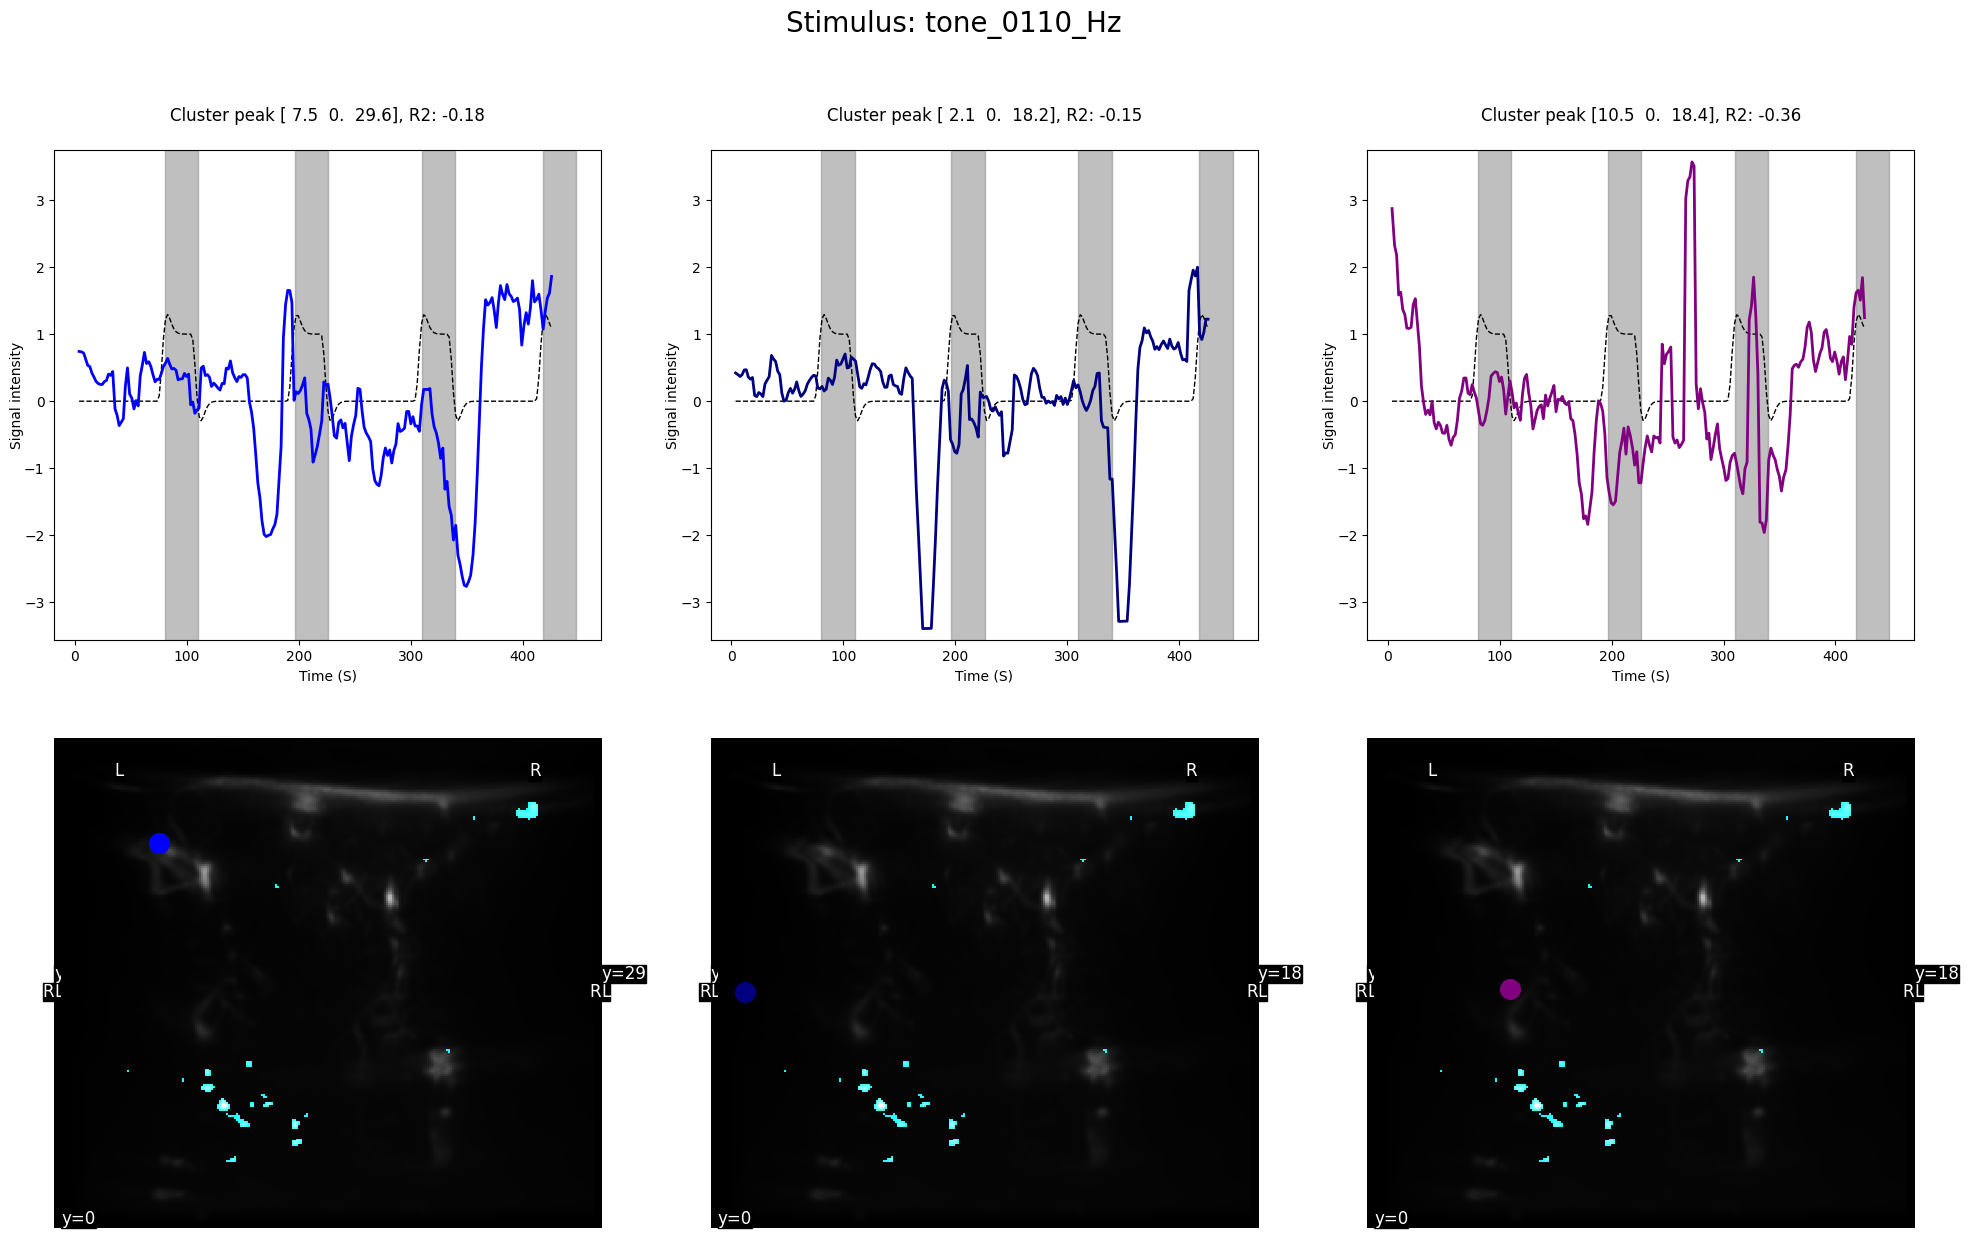

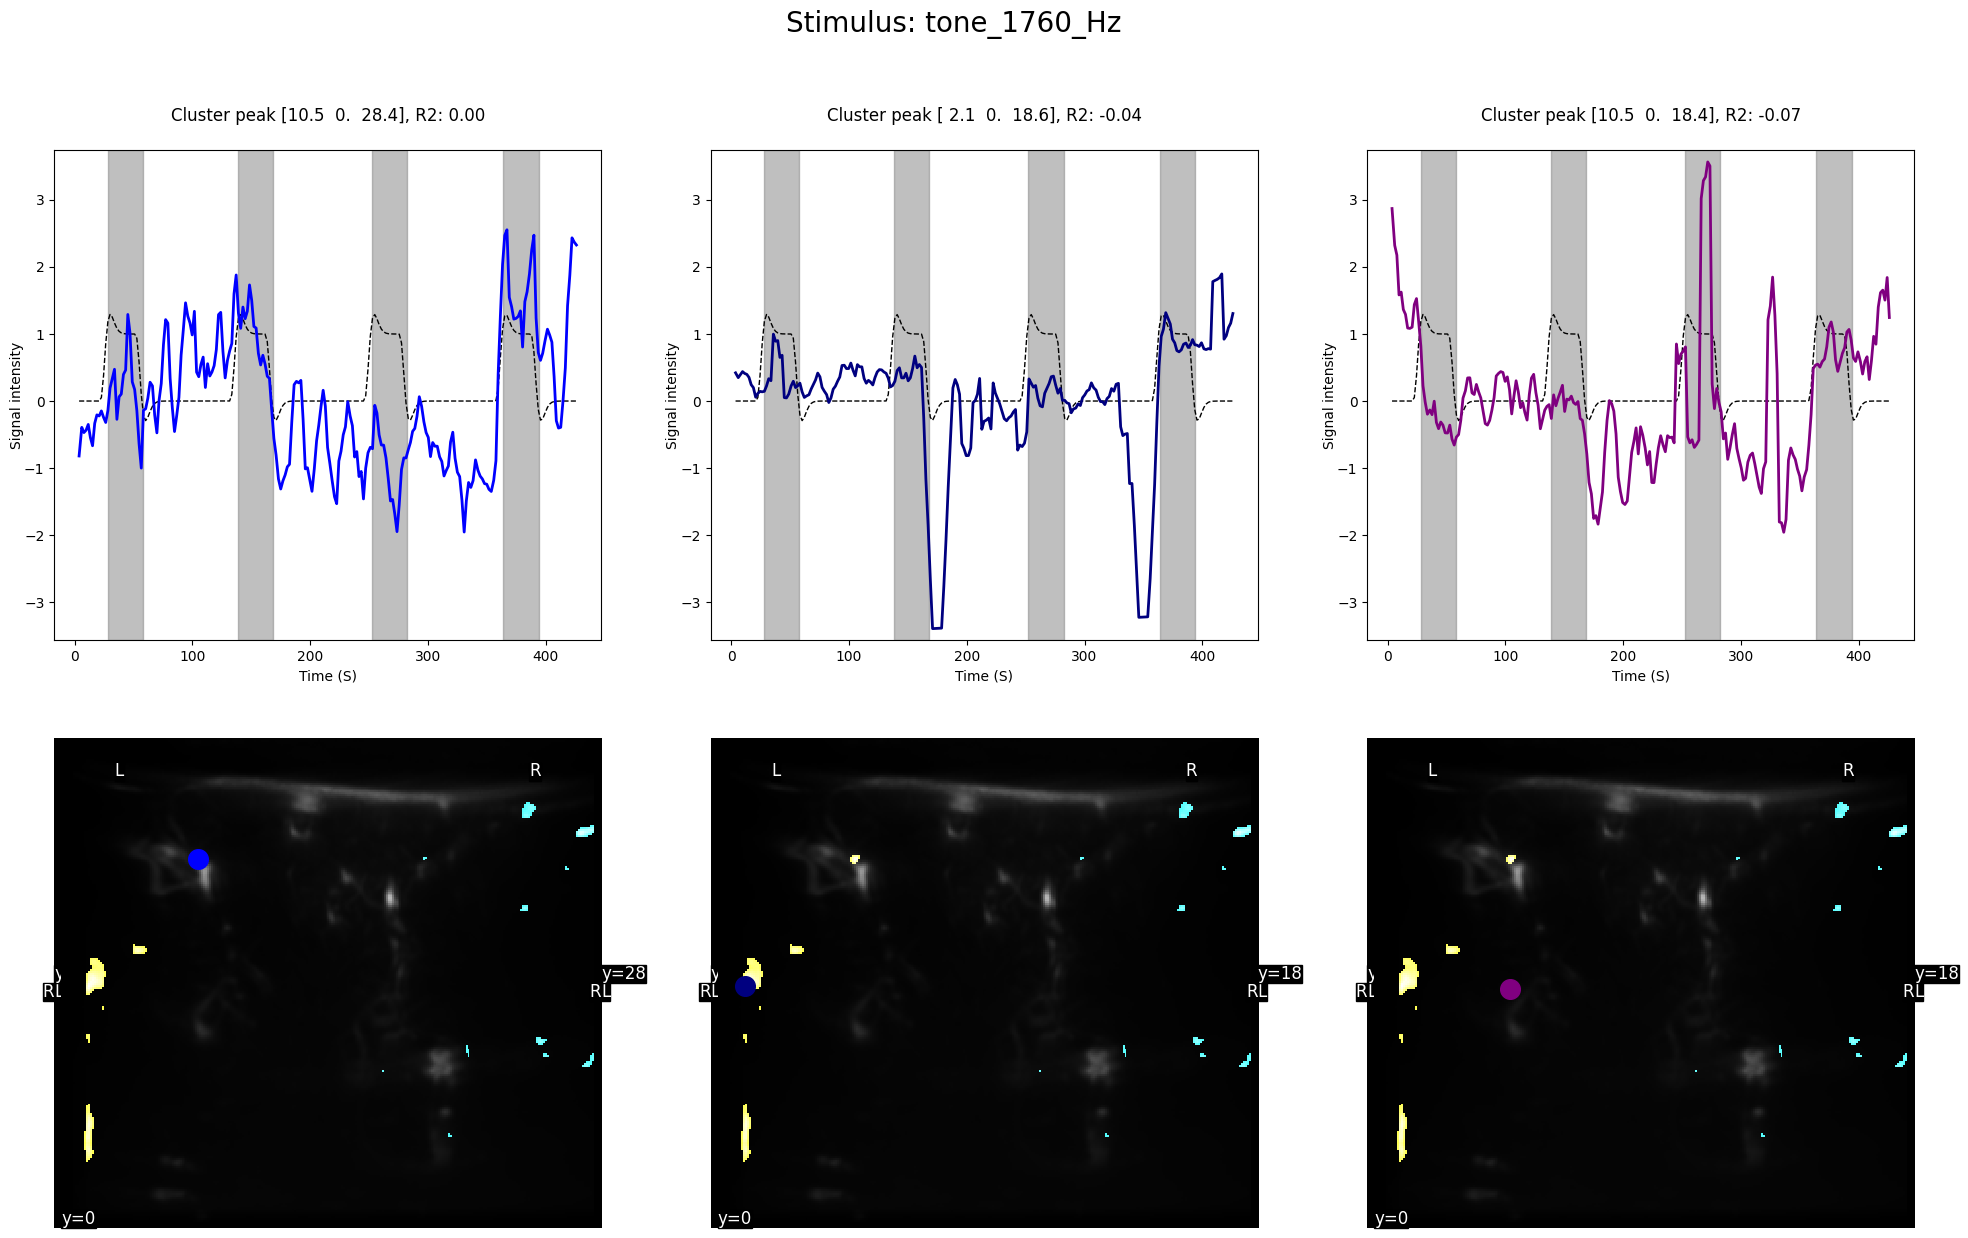

In [77]:
# from nilearn.maskers import NiftiSpheresMasker
# from nilearn.reporting import get_clusters_table
# import numpy as np

# stat_threshold = 1
# num_locations = 2  # How many ROIs to visualize. An additional random ROI will be added

# # Find ROIs by identifying the locations that show a significant response to the stimulus
# mean_image = mean_img(nifti_data)

# # Loop over all conditions in basic_contrasts
# for contrast_id, contrast_val in basic_contrasts.items():
#     if contrast_id not in ['drift_1', 'constant','tx','ty','rot']:
#         print(f"Processing contrast: {contrast_id}")
#         z_map = fmri_glm.compute_contrast(contrast_val, output_type="stat")
#         table = get_clusters_table(z_map, stat_threshold=stat_threshold, cluster_threshold=20)
#         table.set_index("Cluster ID", drop=True)

#         if not table.empty and len(table) >= num_locations:
#             # get the num_locations largest clusters' max x, y, and z coordinates
#             coords = table.loc[range(0, num_locations), ["X", "Y", "Z"]].values
#             coords = np.vstack([coords, [10.45000061, 0., 18.40000045]])

#             # Now use the ROIs to extract the time series 
#             masker = NiftiSpheresMasker(
#                 coords,
#                 radius=0.1,  # specifies the size of the spherical region around each given coordinate from which the signal will be extracted
#                 detrend=True,
#                 standardize="zscore",  # zscore psc
#                 t_r=3.5,
#                 memory_level=1,
#                 verbose=0,
#             )
#             real_timeseries = masker.fit_transform(nifti_data)
#             predicted_timeseries = np.tile(design_matrix[contrast_id].values, (real_timeseries.shape[1], 1)).T

#             from sklearn.metrics import r2_score

#             # Calculate the R-squared value for each ROI
#             r_squared_values = []
#             for i in range(real_timeseries.shape[1]):
#                 r_squared = r2_score(real_timeseries[:, i], predicted_timeseries[:, i])
#                 r_squared_values.append(r_squared)
            
#             # Plotting the time series for each ROI and the corresponding location of each ROI
#             colors = ["blue", "navy", "purple", "magenta", "olive", "teal"]
#             N = real_timeseries.shape[-1]
#             fig1, axs1 = plt.subplots(2, N)
#             fig1.suptitle(f"Stimulus: {contrast_id}", fontsize=20)  # Set the title of the figure with a bigger font size
#             # get plot limits, common across all axis
#             mx = real_timeseries.max() + 0.05 * real_timeseries.max()
#             mn = real_timeseries.min() + 0.05 * real_timeseries.min()

#             for i in range(N):
#                 # plotting time series
#                 axs1[0, i].set_title(f"Cluster peak {coords[i].round(1)}, R2: {r_squared_values[i]:.2f}\n")
#                 if masker.standardize != "psc":
#                     axs1[0, i].plot(probe_events['time_stamp'], predicted_timeseries[:, i], c="k", ls="--", lw=1)

#                 axs1[0, i].plot(probe_events['time_stamp'], real_timeseries[:, i], c=colors[i], lw=2)

#                 axs1[0, i].set_xlabel("Time (S)")

#                 if masker.standardize == "psc":
#                     axs1[0, i].set_ylabel('Percent Signal Change', labelpad=0)
#                 else:
#                     axs1[0, i].set_ylabel("Signal intensity", labelpad=0)

#                 # plotting image below the time series
#                 for index, row in task_events.iterrows():
#                     if row['trial_type'] == contrast_id and row['onset'] > probe_events['time_stamp'].iloc[0]:
#                         axs1[0, i].axvspan(row['onset'] + behavior_offset, row['onset'] + row['duration'] + behavior_offset, color='gray', alpha=0.5)
#                 roi_img = plotting.plot_stat_map(
#                     z_map,
#                     cut_coords=coords[i],
#                     threshold=4,
#                     figure=fig1,
#                     axes=axs1[1, i],
#                     display_mode="y",
#                     colorbar=False,
#                     bg_img=mean_image,
#                 )

#                 axs1[0, i].set_ylim(mn, mx)
#                 roi_img.add_markers([coords[i]], colors[i], 200)
#             fig1.set_size_inches(24, 14)
#         else:
#             print(f"No valid clusters found for {contrast_id} that meet the criteria.")